# Phase 3 — Data Linking & Modeling
## Pharmaceutical Sales: Entity Resolution & Star-Schema Construction

> **Context:** No global keys exist across warehouses. Keys such as `account_id`,
> `prod_id`, and `user_id` are local to each supplier system.  
> This notebook performs entity resolution, builds surrogate keys, and
> produces a clean **star-schema** data model:
>
> | Layer | Table |
> |---|---|
> | **Fact** | `fact_sales` — one row per invoice line item |
> | **Dim** | `dim_customer` — pharmacies (entity-resolved) |
> | **Dim** | `dim_product` — products (supplier-scoped keys) |
> | **Dim** | `dim_sales_rep` — field representatives |
> | **Dim** | `dim_geography` — city / region / area hierarchy |
> | **Dim** | `dim_supplier` — suppliers & branches |
> | **Dim** | `dim_date` — calendar dimension |

---
### Table of Contents
1. [Setup & Load](#1)
2. [Exploratory Key Audit](#2)
3. [Entity Resolution Findings](#3)
4. [dim_geography](#4)
5. [dim_supplier](#5)
6. [dim_product](#6)
7. [dim_customer (Pharmacy)](#7)
8. [dim_sales_rep](#8)
9. [dim_date](#9)
10. [fact_sales](#10)
11. [Model Validation](#11)
12. [Schema Diagram](#12)
13. [Export](#13)


## 1. Setup & Load <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import os, warnings, hashlib
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.4f}".format)
pd.set_option("display.max_colwidth", 60)

FILE_PATH = "updated16_file.csv"   # adjust if needed
df = pd.read_csv(FILE_PATH)

print(f"Rows    : {len(df):,}")
print(f"Columns : {df.columns.tolist()}")
df.head(3)


Rows    : 10,000
Columns : ['id', 'supplier_id', 'invoice_id', 'prod_id', 'product_name', 'quantity', 'discount', 'total_amount', 'account_id', 'account_name', 'account_address', 'user_id', 'user_name', 'employee_name', 'city', 'region', 'area', 'area_id', 'creation_date', 'created_at', 'branch_code', 'Global_Account_ID']


,id,supplier_id,invoice_id,prod_id,product_name,quantity,discount,total_amount,account_id,account_name,account_address,user_id,user_name,employee_name,city,region,area,area_id,creation_date,created_at,branch_code,Global_Account_ID
0,48652728,59,32259,7,سيبروسين مرهم س ج,10,15.0000,178.5000,637,صيدليه مها مديريه امن الجيزه ش,كوبري الجلاء ميدان فيني الدقي,6,نهى الدالى,نهى الدالى,الجيزة,القاهرة الكبرى,الجيزة,17.0000,2025-05-25 13:43:10,2026-05-19 16:29:03,3.0000,GLB_0001
1,48652935,59,32281,7,سيبروسين مرهم س ج,3,15.0000,53.5500,4365,صيدليه السعدني فيصل,شارع مصرف جلال خلف فندق قاعود بجوار مسجد,6,نهى الدالى,نهى الدالى,الجيزة,القاهرة الكبرى,فيصل,99.0000,2025-05-25 14:35:04,2026-05-19 16:29:03,2.0000,GLB_0002
2,48653089,59,32301,7,سيبروسين مرهم س ج,2,21.0000,33.1800,3297,صيدليه مني احمد امبابه,شارع جمال عبد الناصر امام مدرسه تبارك الخاصه,137,اسماء رجب,اسماء رجب,الجيزة,القاهرة الكبرى,إمبابة,9.0000,2025-05-25 15:21:21,2026-05-19 16:29:03,4.0000,GLB_0003


## 2. Exploratory Key Audit <a id='2'></a>

Before building any dimension we must understand how keys behave
**within and across supplier systems**.  
Since there is no shared global key, every column is treated as
a candidate entity identifier that requires validation.


In [2]:
def cardinality_report(df):
    cols = ['id','invoice_id','prod_id','product_name',
            'account_id','account_name','Global_Account_ID',
            'user_id','user_name','employee_name',
            'supplier_id','branch_code',
            'city','region','area','area_id']
    rows = []
    for c in cols:
        rows.append({
            "column": c,
            "unique_values": df[c].nunique(),
            "null_count":    df[c].isna().sum(),
            "null_%":        round(df[c].isna().sum() / len(df) * 100, 1),
        })
    return pd.DataFrame(rows)

cardinality_report(df)


,column,unique_values,null_count,null_%
0,id,10000,0,0.0000
1,invoice_id,2937,0,0.0000
2,prod_id,4776,0,0.0000
3,product_name,5043,0,0.0000
4,account_id,1053,0,0.0000
5,account_name,1085,0,0.0000
6,Global_Account_ID,1092,0,0.0000
7,user_id,68,0,0.0000
8,user_name,89,512,5.1000
9,employee_name,96,0,0.0000


In [3]:
# ── Key consistency checks ──────────────────────────────────────────
checks = {
    "account_id  → account_name (1-to-1?)":
        df.groupby("account_id")["account_name"].nunique().gt(1).sum(),
    "account_name → account_id  (1-to-1?)":
        df.groupby("account_name")["account_id"].nunique().gt(1).sum(),
    "Global_Account_ID → account_name (1-to-1?)":
        df.groupby("Global_Account_ID")["account_name"].nunique().gt(1).sum(),
    "account_name → Global_Account_ID (1-to-1?)":
        df.groupby("account_name")["Global_Account_ID"].nunique().gt(1).sum(),
    "prod_id → product_name  (1-to-1 globally?)":
        df.groupby("prod_id")["product_name"].nunique().gt(1).sum(),
    "prod_id + supplier_id → product_name (1-to-1 within supplier?)":
        df.groupby(["prod_id","supplier_id"])["product_name"].nunique().gt(1).sum(),
    "user_id → employee_name (1-to-1?)":
        df.groupby("user_id")["employee_name"].nunique().gt(1).sum(),
    "area   → area_id  (1-to-1?)":
        df.groupby("area")["area_id"].nunique().gt(1).sum(),
    "area_id → area    (1-to-1?)":
        df.groupby("area_id")["area"].nunique().gt(1).sum(),
    "invoice_id spans >1 supplier":
        df.groupby("invoice_id")["supplier_id"].nunique().gt(1).sum(),
    "invoice_id spans >1 pharmacy":
        df.groupby("invoice_id")["account_name"].nunique().gt(1).sum(),
}

result = pd.DataFrame({"Check": checks.keys(), "Violations": checks.values()})
result["Status"] = result["Violations"].apply(lambda v: "✅ Clean" if v == 0 else f"⚠️  {v} violations")
result


,Check,Violations,Status
0,account_id → account_name (1-to-1?),51,⚠️ 51 violations
1,account_name → account_id (1-to-1?),18,⚠️ 18 violations
2,Global_Account_ID → account_name (1-to-1?),0,✅ Clean
3,account_name → Global_Account_ID (1-to-1?),7,⚠️ 7 violations
4,prod_id → product_name (1-to-1 globally?),356,⚠️ 356 violations
5,prod_id + supplier_id → product_name (1-to-1 within supp...,0,✅ Clean
6,user_id → employee_name (1-to-1?),32,⚠️ 32 violations
7,area → area_id (1-to-1?),0,✅ Clean
8,area_id → area (1-to-1?),0,✅ Clean
9,invoice_id spans >1 supplier,119,⚠️ 119 violations


## 3. Entity Resolution Findings & Key Decisions <a id='3'></a>

Based on the audit above, here is the resolution strategy for each entity:

### 🏥 Customer (Pharmacy)
| Field | Finding | Decision |
|---|---|---|
| `account_id` | 51 IDs map to >1 name — **not a stable key** | ❌ Do not use as PK |
| `account_name` | 18 names share IDs across suppliers | ⚠️ Use as canonical label only |
| `Global_Account_ID` | ✅ 1-to-1 with `account_name` | ✅ **Use as customer surrogate key** |

> `Global_Account_ID` is the entity-resolved key produced in Phase 1. It is the only
> field that unambiguously identifies a pharmacy across all supplier warehouses.

---
### 💊 Product
| Field | Finding | Decision |
|---|---|---|
| `prod_id` (global) | Same ID → different product names across suppliers | ❌ Not a global key |
| `(prod_id, supplier_id)` | ✅ 1-to-1 with `product_name` within each supplier | ✅ **Composite key within supplier** |

> Products must be scoped to their supplier. A surrogate `product_sk` is derived as
> the hash of `(prod_id, supplier_id)`.

---
### 👤 Sales Representative
| Field | Finding | Decision |
|---|---|---|
| `user_id` | 32 IDs → multiple employee names; `user_id=0` is a system/bulk entry | ❌ Not reliable |
| `user_name` | 512 nulls (all from supplier 67) | ⚠️ Partial coverage |
| `employee_name` | 96 unique, **0 nulls** | ✅ **Use as canonical rep key** |

---
### 🌍 Geography
| Field | Finding | Decision |
|---|---|---|
| `area` / `area_id` | ✅ Perfect 1-to-1 mapping | ✅ **area_id as geo leaf key** |
| `city` / `region` | 2,996 nulls (30%) — distributed across multiple suppliers | ⚠️ Fill from area lookup where possible |

---
### 🏭 Supplier / Warehouse
| Field | Finding | Decision |
|---|---|---|
| `supplier_id` | 10 unique, stable | ✅ **PK of dim_supplier** |
| `branch_code` | 4,278 nulls; supplier 63 = always null; supplier 80 = 1 branch | ✅ FK within supplier for `dim_branch` sub-entity |

---
### 📅 Date
| Field | Finding | Decision |
|---|---|---|
| `creation_date` | 10 rows = `0000-00-00` (invalid) | Replace with NaT → NULL FK in fact |
| `created_at` | ETL load timestamp — not a business date | Exclude from date dimension |


## 4. `dim_geography` <a id='4'></a>

In [4]:
# ── Step 1: build area → (city, region) lookup from non-null rows ──
geo_lookup = (
    df[df["city"].notna()]
    .groupby(["area_id","area"])
    .agg(city=("city","first"), region=("region","first"))
    .reset_index()
)

# ── Step 2: full area list (incl. those that only appear with nulls) ──
all_areas = (
    df[["area_id","area"]].drop_duplicates()
    .dropna(subset=["area_id"])
    .sort_values("area_id")
    .reset_index(drop=True)
)

dim_geography = all_areas.merge(geo_lookup, on=["area_id","area"], how="left")
dim_geography.rename(columns={"area_id":"geo_key","area":"area_name"}, inplace=True)
dim_geography["geo_key"] = dim_geography["geo_key"].astype(int)
dim_geography = dim_geography[["geo_key","area_name","city","region"]].sort_values("geo_key").reset_index(drop=True)

print(f"dim_geography: {len(dim_geography):,} rows")
print(f"Rows with null city (no coverage in source): {dim_geography['city'].isna().sum()}")
dim_geography.head(10)


dim_geography: 97 rows
Rows with null city (no coverage in source): 0


,geo_key,area_name,city,region
0,1,أبو الريش,القاهرة,القاهرة الكبرى
1,2,أبو النمرس,الجيزة,القاهرة الكبرى
2,3,أبو الهول,الجيزة,القاهرة الكبرى
3,4,أبو رواش,الجيزة,القاهرة الكبرى
4,5,أرض اللواء,الجيزة,القاهرة الكبرى
5,6,أكتوبر,الجيزة,القاهرة الكبرى
6,7,أوسيم,الجيزة,القاهرة الكبرى
7,9,إمبابة,الجيزة,القاهرة الكبرى
8,10,الإخصاص,الجيزة,القاهرة الكبرى
9,11,البحر الأعظم,الجيزة,القاهرة الكبرى


In [5]:
# ── Region → City → Area hierarchy overview ──
print("Geography Hierarchy:")
print(dim_geography.groupby(["region","city"])["area_name"].count().rename("# Areas").to_string())


Geography Hierarchy:
region          city      
الإسكندرية      الإسكندرية     1
الدلتا          الدقهلية       1
القاهرة الكبرى  الجيزة        69
                القاهرة       24
                القليوبية      2


## 5. `dim_supplier` <a id='5'></a>

In [6]:
# ── Supplier dimension ──
dim_supplier = (
    df[["supplier_id"]]
    .drop_duplicates()
    .sort_values("supplier_id")
    .reset_index(drop=True)
)

# Branches: (supplier_id, branch_code) — exclude NaN branch_codes
dim_branch = (
    df[df["branch_code"].notna()][["supplier_id","branch_code"]]
    .drop_duplicates()
    .sort_values(["supplier_id","branch_code"])
    .reset_index(drop=True)
)
dim_branch["branch_code"] = dim_branch["branch_code"].astype(int)

# Annotate supplier with branch count
branch_count = dim_branch.groupby("supplier_id")["branch_code"].nunique().rename("branch_count")
dim_supplier = dim_supplier.merge(branch_count, on="supplier_id", how="left")
dim_supplier["branch_count"] = dim_supplier["branch_count"].fillna(0).astype(int)

print("dim_supplier:")
display(dim_supplier)

print(f"\ndim_branch (supplier × branch): {len(dim_branch):,} rows")
display(dim_branch.head(10))


dim_supplier:


,supplier_id,branch_count
0,59,12
1,60,8
2,63,0
3,67,13
4,69,10
5,72,13
6,73,20
7,75,4
8,76,4
9,80,1



dim_branch (supplier × branch): 85 rows


,supplier_id,branch_code
0,59,1
1,59,2
2,59,3
3,59,4
4,59,5
5,59,6
6,59,7
7,59,9
8,59,50
9,59,51


In [7]:
# ── Note on supplier 63 & 80 ──
print("Supplier 63 — branch_code is always NULL in source data.")
print("  → No branch sub-entity can be created; branch_code = NULL recorded in fact.")
print()
print("Supplier 80 — branch_code is NULL in source; only 1 physical branch inferred.")
print("  → Single-branch supplier; branch dimension row not applicable.")
print()
print("Branch codes that appear in >1 supplier (shared branch codes):")
shared = dim_branch.groupby("branch_code")["supplier_id"].nunique()
print(shared[shared > 1].reset_index().rename(columns={"supplier_id":"supplier_count"}).to_string())
print("  → branch_code is LOCAL to each supplier; composite key (supplier_id, branch_code) required.")


Supplier 63 — branch_code is always NULL in source data.
  → No branch sub-entity can be created; branch_code = NULL recorded in fact.

Supplier 80 — branch_code is NULL in source; only 1 physical branch inferred.
  → Single-branch supplier; branch dimension row not applicable.

Branch codes that appear in >1 supplier (shared branch codes):
    branch_code  supplier_count
0             1               7
1             2               7
2             3               8
3             4               7
4             5               6
5             6               2
6             7               5
7             8               5
8             9               5
9            10               3
10           11               3
11           12               2
12           13               2
  → branch_code is LOCAL to each supplier; composite key (supplier_id, branch_code) required.


## 6. `dim_product` <a id='6'></a>

In [8]:
# ── Product key: (prod_id, supplier_id) is 1-to-1 with product_name ──
# Generate a stable surrogate key via hash
def make_product_sk(row):
    raw = f"{row['supplier_id']}_{row['prod_id']}"
    return int(hashlib.md5(raw.encode()).hexdigest()[:8], 16)

dim_product = (
    df[["prod_id","product_name","supplier_id"]]
    .drop_duplicates(subset=["prod_id","supplier_id"])
    .sort_values(["supplier_id","prod_id"])
    .reset_index(drop=True)
)

dim_product["product_sk"] = dim_product.apply(make_product_sk, axis=1)

# Check surrogate key uniqueness
assert dim_product["product_sk"].nunique() == len(dim_product), "Hash collision — increase hash length!"

dim_product = dim_product[["product_sk","prod_id","supplier_id","product_name"]]
print(f"dim_product: {len(dim_product):,} rows")
print(f"Surrogate key collisions: 0 ✅")
dim_product.head(10)


dim_product: 5,196 rows
Surrogate key collisions: 0 ✅


,product_sk,prod_id,supplier_id,product_name
0,3796077586,7,59,سيبروسين مرهم س ج
1,3531627453,8,59,سيبروسين نقط س ج
2,3646122039,11,59,سيبرو نقط س ج
3,3221630825,14,59,اوركاسين نقط
4,3629440996,16,59,نيوبول نقط
5,939428212,26,59,تيراميسين مرهم للعين س ج
6,2507557523,33,59,جاراميسين مرهم س ج
7,471347659,44,60,فوج اسبراى رجالى انطلاقه برازيلي 120مل
8,2558543250,93,60,ايفا اى كرياتين بلسم عادى
9,4117773068,96,60,ايفا بودرة قدم منتول


In [23]:
# ── Why prod_id alone is NOT a global key ──
global_conflicts = df.groupby("prod_id")["product_name"].nunique()
conflicted = global_conflicts[global_conflicts > 1].reset_index()
conflicted.columns = ["prod_id","distinct_names_globally"]

print(f"prod_ids that resolve to >1 product name ACROSS suppliers: {len(conflicted)}")
print("Sample:")
for _, row in conflicted.head(7).iterrows():
    names = df[df["prod_id"]==row["prod_id"]][["supplier_id","product_name"]].drop_duplicates()
    print(f"  prod_id={row['prod_id']}")
    print(names.to_string(index=False))
    print()


prod_ids that resolve to >1 product name ACROSS suppliers: 356
Sample:
  prod_id=1
 supplier_id          product_name
          69  انتودين 40 مجم اقراص
          73     نيوريماكس 30كبسول
          75 انتودين 40 مجم 3 شريط

  prod_id=7
 supplier_id      product_name
          59 سيبروسين مرهم س ج
          73     سيبروسين مرهم

  prod_id=8
 supplier_id     product_name
          59 سيبروسين نقط س ج
          73     سيبروسين نقط

  prod_id=11
 supplier_id  product_name
          59 سيبرو نقط س ج
          73     سيبرو نقط

  prod_id=14
 supplier_id      product_name
          59      اوركاسين نقط
          73 اوركاسين نقط 5ملى

  prod_id=26
 supplier_id             product_name
          59 تيراميسين مرهم للعين س ج
          73                        0

  prod_id=33
 supplier_id       product_name
          59 جاراميسين مرهم س ج
          69     جاراميسين مرهم
          73     جاراميسين مرهم
          75     جاراميسين مرهم



## 7. `dim_customer` (Pharmacy) <a id='7'></a>

In [10]:
# ── Global_Account_ID is the entity-resolved key from Phase 1 ──
# It maps 1-to-1 with account_name — verified in audit

# Build customer dimension: one row per Global_Account_ID
dim_customer = (
    df.groupby("Global_Account_ID")
    .agg(
        account_name    = ("account_name",    "first"),
        account_address = ("account_address", "first"),
        # carry a representative local account_id (informational only — not a key)
        local_account_id_sample = ("account_id", "first"),
    )
    .reset_index()
    .rename(columns={"Global_Account_ID": "customer_sk"})
    .sort_values("customer_sk")
    .reset_index(drop=True)
)

print(f"dim_customer: {len(dim_customer):,} rows (unique pharmacies)")
print(f"Null addresses: {dim_customer['account_address'].isna().sum()}")
dim_customer.head(10)


dim_customer: 1,092 rows (unique pharmacies)
Null addresses: 73


,customer_sk,account_name,account_address,local_account_id_sample
0,GLB_0001,صيدليه مها مديريه امن الجيزه ش,كوبري الجلاء ميدان فيني الدقي,637
1,GLB_0002,صيدليه السعدني فيصل,شارع مصرف جلال خلف فندق قاعود بجوار مسجد,4365
2,GLB_0003,صيدليه مني احمد امبابه,شارع جمال عبد الناصر امام مدرسه تبارك الخاصه,3297
3,GLB_0004,صيدليه الشفاء بشتيل,شارع الحريه بجوار المدرسه,5734
4,GLB_0005,صيدليه ايمن محمد ارض اللواء,ناصيه بيومي يمين محور 26 يونيو ارض اللواء,6718
5,GLB_0006,صيدليه الحرمين الوراق,77شارع ترعه السواحل وراق الحضر امام برج عتابي,3438
6,GLB_0007,صيدليه تقي مصطفي فيصل,شارع محمود علي المنشيه فيصل اسامه محمد,7833
7,GLB_0008,صيدليه النخبه فيصل,12 شارع وصفي ع ناصيه قهوه السكريه التعاون فيصل,3708
8,GLB_0009,صيدليه محمود العزباوي الجلاتمه,الجلاتمه,5433
9,GLB_0010,صيدليه فاطمه الزهراء الوراق,شارع التل,7302


In [11]:
# ── Document why account_id is NOT used as customer key ──
aid_multi = df.groupby("account_id")["Global_Account_ID"].nunique()
print("account_ids that map to >1 Global_Account_ID (i.e. >1 real pharmacy):")
bad = aid_multi[aid_multi > 1].reset_index()
bad.columns = ["account_id","distinct_global_ids"]
display(bad)
print()
print("This confirms account_id is a LOCAL warehouse key, not a global entity key.")
print("Global_Account_ID (from Phase 1 entity resolution) is the correct customer surrogate.")


account_ids that map to >1 Global_Account_ID (i.e. >1 real pharmacy):


,account_id,distinct_global_ids
0,176,2
1,180,2
2,186,2
3,194,2
4,219,2
5,265,2
6,492,2
7,670,2
8,701,2
9,792,2



This confirms account_id is a LOCAL warehouse key, not a global entity key.
Global_Account_ID (from Phase 1 entity resolution) is the correct customer surrogate.


## 8. `dim_sales_rep` <a id='8'></a>

In [12]:
# ── employee_name: 96 unique values, 0 nulls — most stable rep identifier ──
# user_id is unreliable (same id → multiple reps across suppliers)
# user_name has 512 nulls (all from supplier 67)

dim_sales_rep = (
    df.groupby("employee_name")
    .agg(
        # Take the most frequent user_id associated with this employee
        primary_user_id   = ("user_id", lambda x: x.mode()[0] if len(x) > 0 else np.nan),
        # user_name — take first non-null
        sample_user_name  = ("user_name", lambda x: x.dropna().iloc[0] if x.notna().any() else np.nan),
        supplier_count    = ("supplier_id", "nunique"),
        transaction_count = ("id", "count"),
    )
    .reset_index()
    .rename(columns={"employee_name": "rep_sk"})
    .sort_values("rep_sk")
    .reset_index(drop=True)
)

# Integer surrogate key
dim_sales_rep.insert(0, "rep_id", range(1, len(dim_sales_rep)+1))

print(f"dim_sales_rep: {len(dim_sales_rep):,} rows")
print(f"Reps active across >1 supplier: {(dim_sales_rep['supplier_count']>1).sum()}")
dim_sales_rep.head(10)


dim_sales_rep: 96 rows
Reps active across >1 supplier: 7


,rep_id,rep_sk,primary_user_id,sample_user_name,supplier_count,transaction_count
0,1,CLUSTER,53,CLUSTER,1,129
1,2,I-SUPPLY,11,I-SUPPLY,1,17
2,3,I-SUPPLY2,11,I-SUPPLY,1,21
3,4,MOSTAFA,2,MENESI,1,301
4,5,SARA,2,محمد فتحي,1,317
5,6,ابو عز,2,اسلام احمد,1,208
6,7,احمد الشرقاوى,6,نهى الدالى,1,6
7,8,احمد حمدي - موزع,154,محمد فوزى,1,15
8,9,احمد فؤاد,83,أ / محمد محروس,1,333
9,10,احمد ياسين مخزن,125,ندى محمود,1,30


In [13]:
# ── Highlight user_id=0 anomaly ──
print("user_id=0 rows in source:", len(df[df["user_id"]==0]))
print("These are bulk/system entries attributed to employee 'سامى - مدير مبيعات'")
print("They will be linked by employee_name in the fact table — no data loss.")
print()

# Show user_id conflicts
uid_multi = df.groupby("user_id")["employee_name"].nunique()
print(f"user_ids with >1 employee_name: {uid_multi.gt(1).sum()}")
print("→ user_id is NOT a reliable rep key across suppliers.")


user_id=0 rows in source: 10
These are bulk/system entries attributed to employee 'سامى - مدير مبيعات'
They will be linked by employee_name in the fact table — no data loss.

user_ids with >1 employee_name: 32
→ user_id is NOT a reliable rep key across suppliers.


## 9. `dim_date` <a id='9'></a>

In [14]:
# ── Parse creation_date; handle 0000-00-00 invalid rows ──
df["_date_parsed"] = pd.to_datetime(df["creation_date"], errors="coerce")

valid_dates = df["_date_parsed"].dropna()
date_range  = pd.date_range(start=valid_dates.min().date(),
                             end=valid_dates.max().date(),
                             freq="D")

dim_date = pd.DataFrame({"full_date": date_range})
dim_date["date_sk"]      = dim_date["full_date"].dt.strftime("%Y%m%d").astype(int)
dim_date["year"]         = dim_date["full_date"].dt.year
dim_date["quarter"]      = dim_date["full_date"].dt.quarter
dim_date["month"]        = dim_date["full_date"].dt.month
dim_date["month_name"]   = dim_date["full_date"].dt.strftime("%B")
dim_date["week"]         = dim_date["full_date"].dt.isocalendar().week.astype(int)
dim_date["day_of_month"] = dim_date["full_date"].dt.day
dim_date["day_of_week"]  = dim_date["full_date"].dt.dayofweek       # 0=Mon
dim_date["day_name"]     = dim_date["full_date"].dt.strftime("%A")
dim_date["is_weekend"]   = dim_date["day_of_week"].isin([5,6])
dim_date["full_date"]    = dim_date["full_date"].dt.date

print(f"dim_date: {len(dim_date):,} rows")
print(f"Range: {dim_date['full_date'].min()} → {dim_date['full_date'].max()}")
print(f"Invalid source dates (0000-00-00): {df['_date_parsed'].isna().sum()} rows → date_sk = NULL in fact")
dim_date.head(5)


dim_date: 1,429 rows
Range: 2022-07-07 → 2026-06-04
Invalid source dates (0000-00-00): 10 rows → date_sk = NULL in fact


,full_date,date_sk,year,quarter,month,month_name,week,day_of_month,day_of_week,day_name,is_weekend
0,2022-07-07,20220707,2022,3,7,July,27,7,3,Thursday,False
1,2022-07-08,20220708,2022,3,7,July,27,8,4,Friday,False
2,2022-07-09,20220709,2022,3,7,July,27,9,5,Saturday,True
3,2022-07-10,20220710,2022,3,7,July,27,10,6,Sunday,True
4,2022-07-11,20220711,2022,3,7,July,28,11,0,Monday,False


## 10. `fact_sales` <a id='10'></a>

In [15]:
# ── Build product_sk lookup ──
product_sk_lookup = dim_product.set_index(["prod_id","supplier_id"])["product_sk"]

# ── Build rep_id lookup ──
rep_id_lookup = dim_sales_rep.set_index("rep_sk")["rep_id"]

# ── Build date_sk lookup ──
df["_date_str"] = df["_date_parsed"].dt.strftime("%Y%m%d")
date_sk_lookup  = dim_date.set_index("full_date")["date_sk"]
# convert to same format for lookup
df["_date_key"] = pd.to_datetime(df["_date_parsed"], errors="coerce").dt.date

fact_sales = pd.DataFrame({
    # ── Surrogate / grain key ──────────────────────────────────────
    "sale_sk"          : df["id"],                          # line-item PK

    # ── Foreign keys ──────────────────────────────────────────────
    "date_sk"          : df["_date_parsed"].dt.strftime("%Y%m%d")
                            .where(df["_date_parsed"].notna()).astype("Int64"),
    "customer_sk"      : df["Global_Account_ID"],           # → dim_customer
    "product_sk"       : df.set_index(["prod_id","supplier_id"])
                            .index.map(product_sk_lookup).values,
    "rep_id"           : df["employee_name"].map(rep_id_lookup).astype("Int64"),
    "geo_key"          : df["area_id"].where(df["area_id"].notna()).astype("Int64"),
    "supplier_id"      : df["supplier_id"],                 # → dim_supplier
    "branch_code"      : df["branch_code"].where(df["branch_code"].notna()).astype("Int64"),

    # ── Degenerate dimensions (kept on fact for drill-through) ────
    "invoice_id"       : df["invoice_id"],
    "invoice_date"     : df["creation_date"],

    # ── Measures ──────────────────────────────────────────────────
    "quantity"         : df["quantity"],
    "discount_pct"     : df["discount"],
    "line_amount"      : df["total_amount"],
})

print(f"fact_sales: {len(fact_sales):,} rows")
print(f"Null date_sk (invalid dates): {fact_sales['date_sk'].isna().sum()}")
print(f"Null geo_key (missing city/area): {fact_sales['geo_key'].isna().sum()}")
print(f"Null branch_code (suppliers 63,80 + others): {fact_sales['branch_code'].isna().sum()}")
fact_sales.head(5)


fact_sales: 10,000 rows
Null date_sk (invalid dates): 10
Null geo_key (missing city/area): 2996
Null branch_code (suppliers 63,80 + others): 4278


,sale_sk,date_sk,customer_sk,product_sk,rep_id,geo_key,supplier_id,branch_code,invoice_id,invoice_date,quantity,discount_pct,line_amount
0,48652728,20250525,GLB_0001,3796077586,91,17,59,3,32259,2025-05-25 13:43:10,10,15.0000,178.5000
1,48652935,20250525,GLB_0002,3796077586,91,99,59,2,32281,2025-05-25 14:35:04,3,15.0000,53.5500
2,48653089,20250525,GLB_0003,3796077586,13,9,59,4,32301,2025-05-25 15:21:21,2,21.0000,33.1800
3,48653301,20250525,GLB_0004,3796077586,13,69,59,4,32334,2025-05-25 20:49:54,5,20.0000,84.0000
4,49140754,20260412,GLB_0001,3796077586,91,17,59,3,100804,2026-04-12 13:51:32,10,17.0000,174.3000


In [16]:
# ── Grain verification ──────────────────────────────────────────────
print("Grain: one row = one invoice line item (product sold on an invoice)")
print(f"  sale_sk unique: {fact_sales['sale_sk'].nunique() == len(fact_sales)} — {'✅ PK is clean' if fact_sales['sale_sk'].nunique() == len(fact_sales) else '❌ duplicates!'}")

# Invoice-level aggregation (for reference)
invoice_summary = (
    fact_sales.groupby(["invoice_id","customer_sk","supplier_id"])
    .agg(
        invoice_lines=("sale_sk","count"),
        invoice_total=("line_amount","sum"),
        invoice_qty=("quantity","sum"),
    )
    .reset_index()
)
print(f"\nUnique invoices: {invoice_summary['invoice_id'].nunique():,}")
print(f"Invoices spanning >1 supplier (cross-wh invoices): "
      f"{invoice_summary.groupby('invoice_id')['supplier_id'].nunique().gt(1).sum()}")


Grain: one row = one invoice line item (product sold on an invoice)
  sale_sk unique: True — ✅ PK is clean

Unique invoices: 2,937
Invoices spanning >1 supplier (cross-wh invoices): 119


## 11. Model Validation — Referential Integrity <a id='11'></a>

In [17]:
print("=" * 60)
print("REFERENTIAL INTEGRITY CHECKS")
print("=" * 60)

customer_keys = set(dim_customer["customer_sk"])
product_keys  = set(dim_product["product_sk"])
rep_keys      = set(dim_sales_rep["rep_id"])
geo_keys      = set(dim_geography["geo_key"])
supplier_keys = set(dim_supplier["supplier_id"])
date_keys     = set(dim_date["date_sk"].astype(str))

checks_ri = {
    "fact.customer_sk  ∈ dim_customer":
        fact_sales["customer_sk"].dropna().isin(customer_keys).all(),
    "fact.product_sk   ∈ dim_product":
        pd.Series(fact_sales["product_sk"]).isin(product_keys).all(),
    "fact.rep_id       ∈ dim_sales_rep":
        fact_sales["rep_id"].dropna().isin(rep_keys).all(),
    "fact.geo_key      ∈ dim_geography":
        fact_sales["geo_key"].dropna().astype(int).isin(geo_keys).all(),
    "fact.supplier_id  ∈ dim_supplier":
        fact_sales["supplier_id"].isin(supplier_keys).all(),
    "fact.date_sk      ∈ dim_date (non-null)":
        fact_sales["date_sk"].dropna().astype(str).isin(date_keys).all(),
}

for check, passed in checks_ri.items():
    print(f"  {'✅' if passed else '❌'} {check}: {'PASS' if passed else 'FAIL'}")


REFERENTIAL INTEGRITY CHECKS
  ✅ fact.customer_sk  ∈ dim_customer: PASS
  ✅ fact.product_sk   ∈ dim_product: PASS
  ✅ fact.rep_id       ∈ dim_sales_rep: PASS
  ✅ fact.geo_key      ∈ dim_geography: PASS
  ✅ fact.supplier_id  ∈ dim_supplier: PASS
  ✅ fact.date_sk      ∈ dim_date (non-null): PASS


In [18]:
# ── Row-count reconciliation ──────────────────────────────────────────
print("\nROW COUNT RECONCILIATION")
print("-" * 40)
print(f"  Source rows               : {len(df):,}")
print(f"  fact_sales rows           : {len(fact_sales):,}")
print(f"  Match                     : {'✅' if len(df) == len(fact_sales) else '❌'}")

print("\nDIMENSION SIZES")
print("-" * 40)
for name, tbl in [("dim_geography", dim_geography),
                   ("dim_supplier",  dim_supplier),
                   ("dim_product",   dim_product),
                   ("dim_customer",  dim_customer),
                   ("dim_sales_rep", dim_sales_rep),
                   ("dim_date",      dim_date),
                   ("fact_sales",    fact_sales)]:
    print(f"  {name:<20}: {len(tbl):>6,} rows")



ROW COUNT RECONCILIATION
----------------------------------------
  Source rows               : 10,000
  fact_sales rows           : 10,000
  Match                     : ✅

DIMENSION SIZES
----------------------------------------
  dim_geography       :     97 rows
  dim_supplier        :     10 rows
  dim_product         :  5,196 rows
  dim_customer        :  1,092 rows
  dim_sales_rep       :     96 rows
  dim_date            :  1,429 rows
  fact_sales          : 10,000 rows


In [19]:
# ── Revenue reconciliation ──
src_total  = df["total_amount"].sum()
fact_total = fact_sales["line_amount"].sum()
print(f"\nREVENUE RECONCILIATION")
print(f"  Source total_amount : EGP {src_total:>14,.2f}")
print(f"  fact line_amount    : EGP {fact_total:>14,.2f}")
print(f"  Delta               : EGP {abs(src_total-fact_total):>14,.2f}")
print(f"  Match               : {'✅' if abs(src_total-fact_total) < 0.01 else '❌'}")



REVENUE RECONCILIATION
  Source total_amount : EGP   2,593,247.27
  fact line_amount    : EGP   2,593,247.27
  Delta               : EGP           0.00
  Match               : ✅


## 12. Star-Schema Diagram <a id='12'></a>

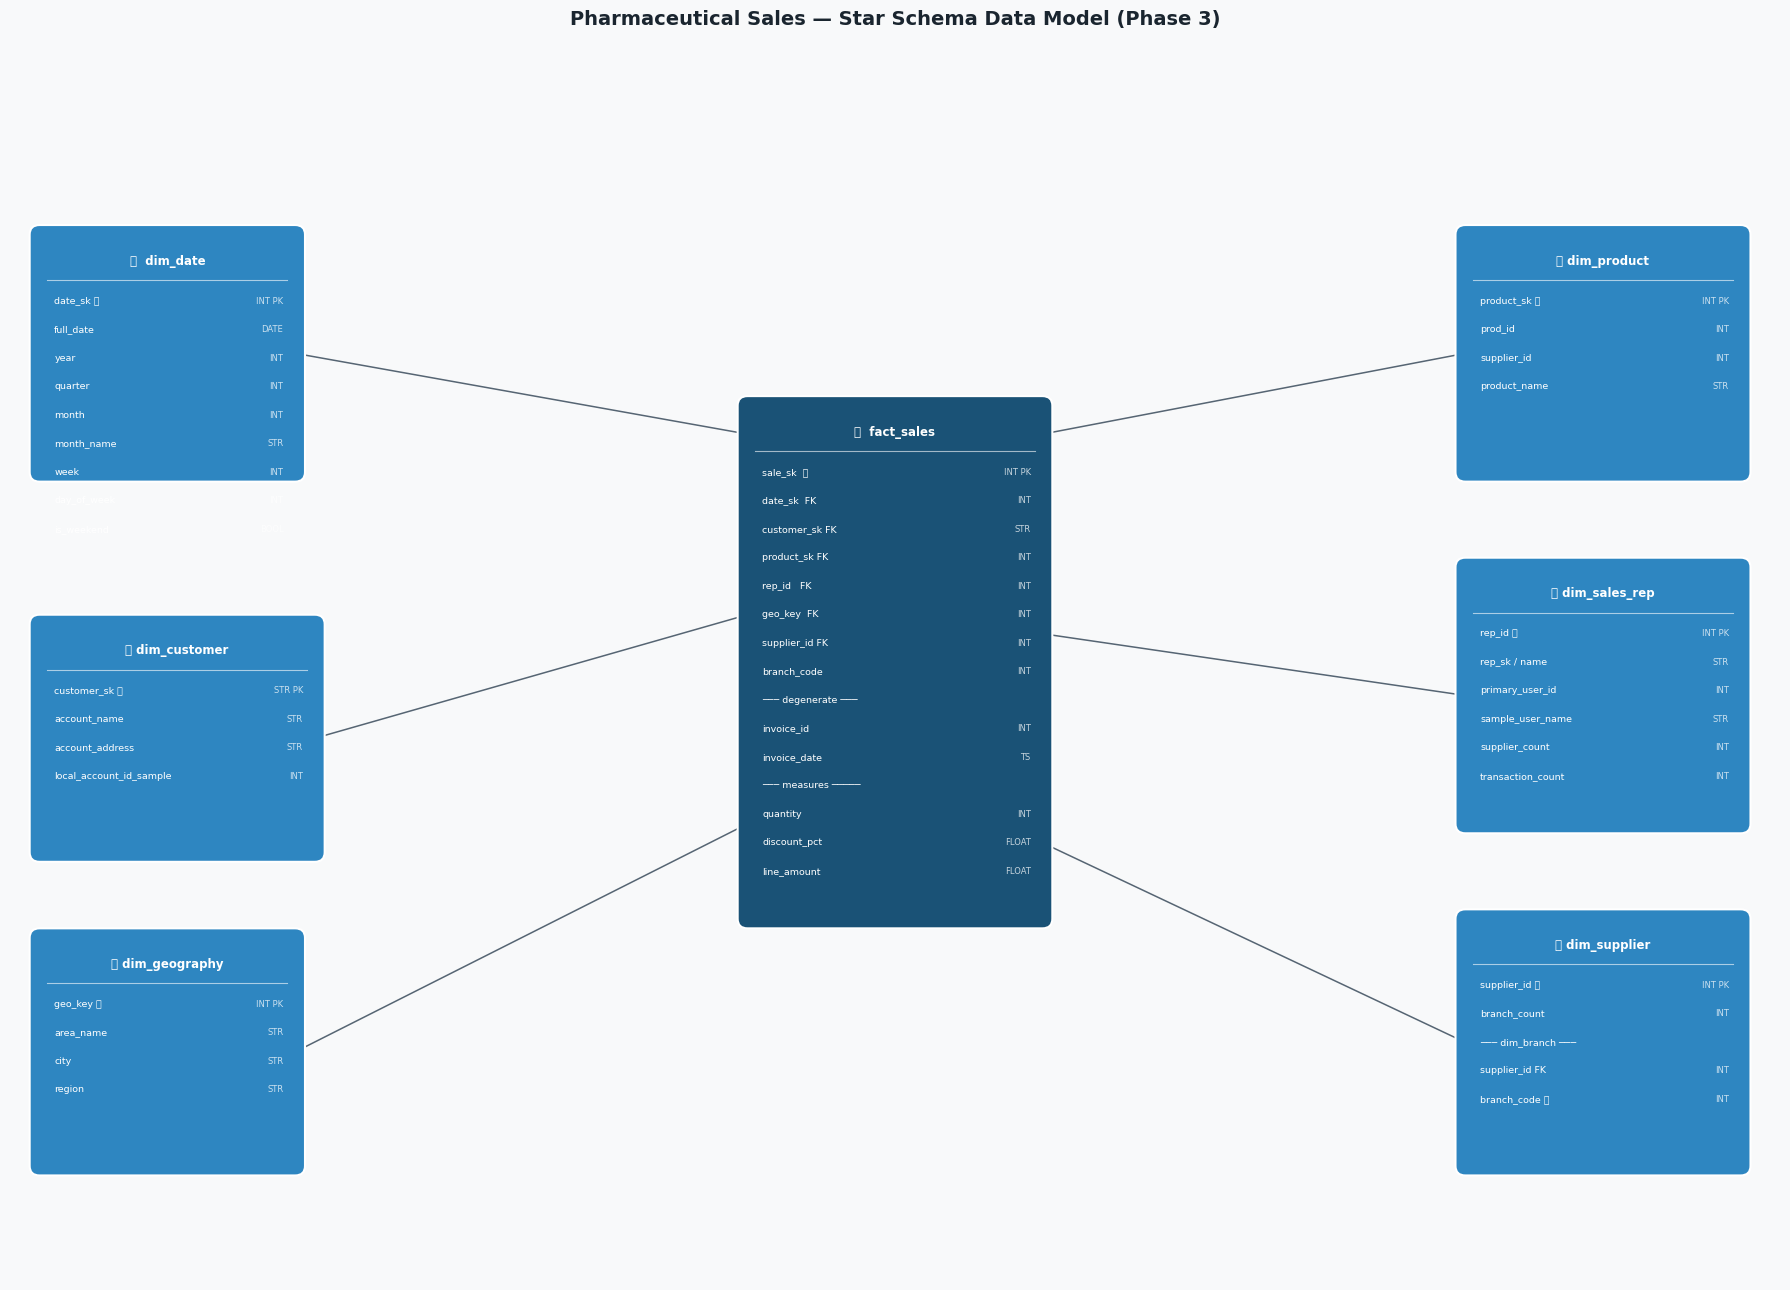

Saved: star_schema_diagram.png


In [20]:
try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

    fig, ax = plt.subplots(figsize=(18, 13))
    ax.set_xlim(0, 18)
    ax.set_ylim(0, 13)
    ax.axis("off")
    ax.set_facecolor("#f8f9fa")
    fig.patch.set_facecolor("#f8f9fa")

    # ── colour palette ──
    C_FACT = "#1a5276"
    C_DIM  = "#2e86c1"
    C_TXT  = "white"
    C_LINE = "#566573"
    C_DEGN = "#7f8c8d"   # degenerate dims

    def draw_table(ax, x, y, w, h, title, fields, color):
        box = FancyBboxPatch((x, y), w, h,
                             boxstyle="round,pad=0.1",
                             facecolor=color, edgecolor="white",
                             linewidth=1.5, zorder=3)
        ax.add_patch(box)
        ax.text(x + w/2, y + h - 0.28, title,
                ha="center", va="center", fontsize=8.5,
                fontweight="bold", color=C_TXT, zorder=4)
        # header underline
        ax.plot([x+0.08, x+w-0.08], [y+h-0.48, y+h-0.48],
                color="white", linewidth=0.8, alpha=0.6, zorder=4)
        for i, (fname, ftype) in enumerate(fields):
            fy = y + h - 0.70 - i * 0.30
            ax.text(x + 0.15, fy, fname,
                    fontsize=6.8, color=C_TXT, va="center", zorder=4)
            ax.text(x + w - 0.12, fy, ftype,
                    fontsize=6, color=C_TXT, va="center",
                    ha="right", alpha=0.75, zorder=4)

    def arrow(ax, x1, y1, x2, y2):
        ax.annotate("",
                    xy=(x2,y2), xytext=(x1,y1),
                    arrowprops=dict(arrowstyle="-|>", color=C_LINE,
                                    lw=1.3, mutation_scale=10),
                    zorder=2)

    # ═══════════════════════════════════════
    # FACT TABLE  (centre)
    # ═══════════════════════════════════════
    fact_fields = [
        ("sale_sk  🔑",  "INT PK"),
        ("date_sk  FK",  "INT"),
        ("customer_sk FK","STR"),
        ("product_sk FK","INT"),
        ("rep_id   FK",  "INT"),
        ("geo_key  FK",  "INT"),
        ("supplier_id FK","INT"),
        ("branch_code",  "INT"),
        ("─── degenerate ───",""),
        ("invoice_id",   "INT"),
        ("invoice_date", "TS"),
        ("─── measures ─────",""),
        ("quantity",     "INT"),
        ("discount_pct", "FLOAT"),
        ("line_amount",  "FLOAT"),
    ]
    fw, fh = 3.0, 5.4
    fx, fy = 7.5, 3.8
    draw_table(ax, fx, fy, fw, fh, "⭐  fact_sales", fact_fields, C_FACT)

    # ═══════════════════════════════════════
    # DIMENSIONS
    # ═══════════════════════════════════════
    dims = [
        # (label, x, y, w, h, fields, cx_fact, cy_fact)
        ("🗓  dim_date", 0.3, 8.5, 2.6, 2.5, [
            ("date_sk 🔑","INT PK"),("full_date","DATE"),("year","INT"),
            ("quarter","INT"),("month","INT"),("month_name","STR"),
            ("week","INT"),("day_of_week","INT"),("is_weekend","BOOL"),
        ], fx, fy+fh-0.3),

        ("🏥 dim_customer", 0.3, 4.5, 2.8, 2.4, [
            ("customer_sk 🔑","STR PK"),("account_name","STR"),
            ("account_address","STR"),("local_account_id_sample","INT"),
        ], fx, fy+3.2),

        ("🌍 dim_geography", 0.3, 1.2, 2.6, 2.4, [
            ("geo_key 🔑","INT PK"),("area_name","STR"),
            ("city","STR"),("region","STR"),
        ], fx, fy+1.0),

        ("💊 dim_product", 14.8, 8.5, 2.8, 2.5, [
            ("product_sk 🔑","INT PK"),("prod_id","INT"),
            ("supplier_id","INT"),("product_name","STR"),
        ], fx+fw, fy+fh-0.3),

        ("👤 dim_sales_rep", 14.8, 4.8, 2.8, 2.7, [
            ("rep_id 🔑","INT PK"),("rep_sk / name","STR"),
            ("primary_user_id","INT"),("sample_user_name","STR"),
            ("supplier_count","INT"),("transaction_count","INT"),
        ], fx+fw, fy+3.0),

        ("🏭 dim_supplier", 14.8, 1.2, 2.8, 2.6, [
            ("supplier_id 🔑","INT PK"),("branch_count","INT"),
            ("─── dim_branch ───",""),
            ("supplier_id FK","INT"),("branch_code 🔑","INT"),
        ], fx+fw, fy+0.8),
    ]

    for label, dx, dy, dw, dh, dfields, acx, acy in dims:
        draw_table(ax, dx, dy, dw, dh, label, dfields, C_DIM)
        # midpoint of dim right or left edge
        if dx < fx:                       # left dims → arrow from right edge
            ax.annotate("",
                        xy=(fx, acy),
                        xytext=(dx+dw, dy+dh/2),
                        arrowprops=dict(arrowstyle="-|>", color=C_LINE,
                                        lw=1.1, mutation_scale=9, connectionstyle="arc3,rad=0.0"),
                        zorder=2)
        else:                             # right dims → arrow from left edge
            ax.annotate("",
                        xy=(fx+fw, acy),
                        xytext=(dx, dy+dh/2),
                        arrowprops=dict(arrowstyle="-|>", color=C_LINE,
                                        lw=1.1, mutation_scale=9, connectionstyle="arc3,rad=0.0"),
                        zorder=2)

    ax.set_title("Pharmaceutical Sales — Star Schema Data Model (Phase 3)",
                 fontsize=14, fontweight="bold", pad=14, color="#1a252f")

    plt.tight_layout()
    plt.savefig("star_schema_diagram.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: star_schema_diagram.png")

except Exception as e:
    print(f"Diagram error: {e}")


## 13. Export Deliverables <a id='13'></a>

In [21]:
import os, shutil

OUT = "phase3_data_model"
os.makedirs(OUT, exist_ok=True)

tables = {
    "dim_geography":  dim_geography,
    "dim_supplier":   dim_supplier,
    "dim_branch":     dim_branch,
    "dim_product":    dim_product,
    "dim_customer":   dim_customer,
    "dim_sales_rep":  dim_sales_rep,
    "dim_date":       dim_date,
    "fact_sales":     fact_sales,
}

for name, tbl in tables.items():
    path = f"{OUT}/{name}.csv"
    tbl.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"  ✅ {name:<22} → {len(tbl):>6,} rows   [{os.path.getsize(path)/1024:>6.1f} KB]")

if os.path.exists("star_schema_diagram.png"):
    shutil.copy("star_schema_diagram.png", f"{OUT}/star_schema_diagram.png")
    print(f"  ✅ star_schema_diagram.png")

print(f"\nAll files saved to: ./{OUT}/")


  ✅ dim_geography          →     97 rows   [   5.9 KB]
  ✅ dim_supplier           →     10 rows   [   0.1 KB]
  ✅ dim_branch             →     85 rows   [   0.6 KB]
  ✅ dim_product            →  5,196 rows   [ 303.0 KB]
  ✅ dim_customer           →  1,092 rows   [ 141.1 KB]
  ✅ dim_sales_rep          →     96 rows   [   4.6 KB]
  ✅ dim_date               →  1,429 rows   [  82.2 KB]
  ✅ fact_sales             → 10,000 rows   [ 843.4 KB]
  ✅ star_schema_diagram.png

All files saved to: ./phase3_data_model/


---
## Phase 3 Summary

### Data Model: Star Schema

```
fact_sales  (10,000 line-item rows)
  │
  ├── dim_date       (date_sk)         — calendar grain: day
  ├── dim_customer   (customer_sk)     — entity-resolved pharmacy ID (Global_Account_ID)
  ├── dim_product    (product_sk)      — supplier-scoped product surrogate
  ├── dim_sales_rep  (rep_id)          — resolved via employee_name (96 reps)
  ├── dim_geography  (geo_key)         — area → city → region hierarchy
  └── dim_supplier   (supplier_id)     — 10 suppliers + dim_branch sub-entity
```

### Key Entity Resolution Decisions

| Entity | Raw Key(s) | Problem | Resolution |
|--------|-----------|---------|------------|
| Customer | `account_id`, `account_name` | `account_id` is local per warehouse; 51 IDs map to >1 pharmacy | Use `Global_Account_ID` from Phase 1 ER |
| Product | `prod_id` | Same `prod_id` = different products across suppliers | Composite key `(prod_id, supplier_id)` → hash surrogate |
| Sales Rep | `user_id`, `user_name` | `user_id` unreliable; `user_name` has nulls | Canonical key = `employee_name` (0 nulls, 96 unique) |
| Geography | `area`, `area_id` | `city`/`region` null in 30% of rows | `area_id` is clean (1-to-1 with `area`); city/region filled via lookup |
| Supplier | `supplier_id` | `branch_code` is local + 4,278 nulls | `supplier_id` as PK; `(supplier_id, branch_code)` as branch composite key |
| Date | `creation_date` | 10 rows have invalid `0000-00-00` | Parse with `errors='coerce'`; invalid → NULL FK in fact |

### Null Coverage in Fact Table
| FK | Null rows | Cause |
|----|-----------|-------|
| `date_sk` | 10 | Invalid source dates |
| `geo_key` | ~2,996 | `area` null in source for certain suppliers |
| `branch_code` | ~4,278 | Supplier 63 (always null) + supplier 80 + others |

All nulls are preserved as NULL FKs — no imputation applied to measures.
